In [2]:
import pandas as pd


In [3]:
df_c = pd.read_csv('child.csv')
df_p = pd.read_csv('parent.csv')

In [4]:
len(df_c), len(df_p)

(1001, 1001)

In [5]:
# change the age records with only extract numbers
df_c['user_age'] = df_c['user_age'].str.extract('(\d+)')
df_p['user_age'] = df_p['user_age'].str.extract('(\d+)')

In [14]:
# Convert age keys to integers for correct numeric sorting
age_child = {int(k): v for k, v in df_c['user_age'].value_counts().to_dict().items()}
age_parent = {int(k): v for k, v in df_p['user_age'].value_counts().to_dict().items()}

# Sort by age (numeric)
age_child = dict(sorted(age_child.items()))
age_parent = dict(sorted(age_parent.items()))

# Print age distribution
print("Child Age Distribution:")
total_children = sum(age_child.values())
for age, count in age_child.items():
    print(f"Age {age}: {count} children")
print(f"Total children: {total_children}")

print("\nParent Age Distribution:")
total_parents = sum(age_parent.values())
for age, count in age_parent.items():
    print(f"Age {age}: {count} parents")
print(f"Total parents: {total_parents}")

Child Age Distribution:
Age 2: 11 children
Age 3: 3 children
Age 4: 4 children
Age 5: 12 children
Age 6: 26 children
Age 7: 38 children
Age 8: 56 children
Age 9: 82 children
Age 10: 160 children
Age 11: 136 children
Age 12: 123 children
Age 13: 215 children
Age 14: 67 children
Age 15: 33 children
Age 16: 10 children
Age 17: 8 children
Age 18: 16 children
Total children: 1000

Parent Age Distribution:
Age 1: 1 parents
Age 2: 41 parents
Age 3: 9 parents
Age 4: 24 parents
Age 5: 49 parents
Age 6: 74 parents
Age 7: 87 parents
Age 8: 129 parents
Age 9: 75 parents
Age 10: 123 parents
Age 11: 45 parents
Age 12: 59 parents
Age 13: 70 parents
Age 14: 25 parents
Age 15: 21 parents
Age 16: 28 parents
Age 17: 10 parents
Age 18: 130 parents
Total parents: 1000


/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_80930/2552343309.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


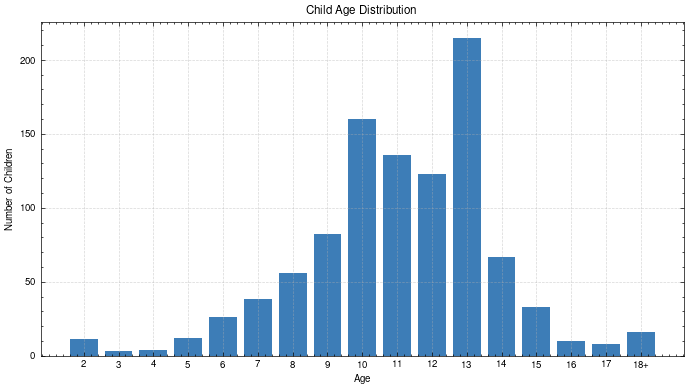

/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_80930/2552343309.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


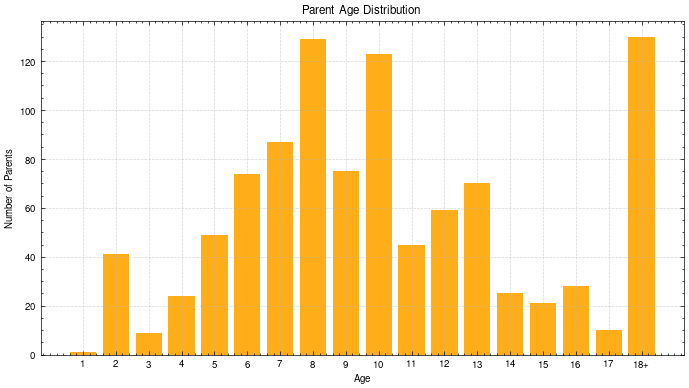

In [39]:
# Convert to pandas Series for plotting
child_series = pd.Series(age_child).sort_index()
parent_series = pd.Series(age_parent).sort_index()

# Rename 18 to '18+' and convert all indices to string for plotting
child_series.index = child_series.index.map(lambda x: '18+' if x == 18 else str(x))
parent_series.index = parent_series.index.map(lambda x: '18+' if x == 18 else str(x))

# Plot child age distribution
plt.figure(figsize=(7, 4))
plt.bar(child_series.index, child_series.values, alpha=0.8)
# plt.plot(child_series.index, child_series.values, marker='o', linestyle='-', label='Child Age Distribution')
plt.title('Child Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Children')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('child_age_distribution.png', dpi=300)
plt.show()

# Plot parent age distribution
plt.figure(figsize=(7, 4))
plt.bar(parent_series.index, parent_series.values, alpha=0.9, color='orange')
# plt.plot(parent_series.index, parent_series.values, marker='o', linestyle='-', label='Parent Age Distribution', color='red')
plt.title('Parent Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Parents')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('parent_age_distribution.png', dpi=300)
plt.show()